In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:\Users\Marcus\Desktop\python pandas\superstore_data\version_control\superstore_clean.csv')
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,31518,CA-2012-169397,2012-12-24,2013-01-09,First Class,JB-15925,Joni Blumstein,Consumer,Dublin,Ohio,...,OFF-BI-10002852,Office Supplies,Binders,Ibico Standard Transparent Covers,19.7760,4,0.70,-13.84,0.79,Medium
1,6224,US-2011-144729,2011-07-21,2011-08-07,First Class,SS-20140,Saphhira Shifley,Corporate,San Miguelito,Panama,...,OFF-FA-10002247,Office Supplies,Fasteners,"Oic Paper Clips, Bulk Pack",11.5440,2,0.40,-5.22,0.97,Medium
2,15333,IT-2014-4749412,2014-09-18,2014-09-28,Standard Class,MB-18085,Mick Brown,Unknown,Birmingham,England,...,OFF-AR-10003113,Office Supplies,Art,"Binney & Smith Pens, Blue",29.8500,5,0.50,-4.80,3.71,Medium
3,49259,NI-2013-4420,2013-04-10,2013-10-26,Standard Class,MP-7965,Michael Paige,Corporate,Lagos,Lagos,...,OFF-AVE-10004512,Office Supplies,Binders,"Avery Hole Reinforcements, Economy",1.3230,1,0.70,-3.09,0.06,Medium
4,24199,IN-2014-14423,2014-10-29,2014-11-27,First Class,DL-12925,Daniel Lacy,Consumer,Kendari,Sulawesi Tenggara,...,FUR-FU-10002362,Furnitures,Furnishings,"Advantus Door Stop, Black",131.4876,4,0.27,25.17,0.00,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51365,17526,ES-2014-2057259,2014-08-02,2014-05-19,First Class,PB-19150,Philip Brown,Consumer,Cagnes-Sur-Mer,Provence-Alpes-Cote D'Azur,...,OFF-PA-10002616,Office Supplies,Paper,"Green Bar Parchment Paper, Multicolor",108.5400,6,0.00,34.56,11.76,Medium
51366,36055,CA-2011-121573,2011-11-03,2011-08-07,Standard Class,SG-20605,Speros Goranitis,Consumer,New York City,New York,...,TEC-PH-10000984,Technology,Phones,Panasonic Kx-Tg9471B,783.9600,4,0.00,219.51,64.42,High
51367,43576,TU-2011-9190,2011-12-23,2012-01-11,Second Class,CM-1830,Cari Macintyre,Corporate,Corum,Corum,...,OFF-KIT-10002357,Office Supplies,Appliances,"Kitchenaid Blender, White",39.8400,1,0.60,-12.96,5.84,Medium
51368,22403,IN-2013-35388,2013-08-07,2013-11-19,Standard Class,IM-15055,Unknown,Consumer,Jakarta,Jakarta,...,OFF-AR-10000058,Office Supplies,Art,"Stanley Canvas, Water Color",38.4345,1,0.27,3.66,2.96,Medium


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51370 entries, 0 to 51369
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51370 non-null  int64  
 1   Order ID        51370 non-null  str    
 2   Order Date      51370 non-null  str    
 3   Ship Date       51370 non-null  str    
 4   Ship Mode       51370 non-null  str    
 5   Customer ID     51370 non-null  str    
 6   Customer Name   51336 non-null  str    
 7   Segment         51370 non-null  str    
 8   City            51351 non-null  str    
 9   State           51339 non-null  str    
 10  Country         51370 non-null  str    
 11  Postal Code     51370 non-null  int64  
 12  Market          51370 non-null  str    
 13  Region          51370 non-null  str    
 14  Product ID      51370 non-null  str    
 15  Category        51370 non-null  str    
 16  Sub-Category    51370 non-null  str    
 17  Product Name    51370 non-null  str    
 1

In [4]:
# What is the direct impact of giving Discounts on overall Profitability? Is there a point where discounting completely destroys margins?

In [5]:
sales_profit_by_discount = df.groupby(df['Discount'].rename('discount_given'))[['Sales','Profit','Discount']].agg(
    total_sales = ('Sales','sum'),
    total_profit = ('Profit','sum'),
    total_discount = ('Discount','sum'),
).round(2).sort_values(by='total_discount', ascending=False)
sales_profit_by_discount

,total_sales,total_profit,total_discount
discount_given,,,
0.40,582601.85,-152909.77,1290.40
0.70,135830.27,-181050.70,1221.50
0.60,181936.88,-161240.44,1192.20
0.20,1203457.84,114491.08,994.00
0.50,314913.41,-154075.46,799.00
0.10,1555613.58,254546.00,398.90
0.47,82601.65,-30894.53,336.05
0.80,20474.57,-38636.71,252.00
0.45,32888.85,-13442.75,144.00


In [6]:
profit_margin = (sales_profit_by_discount['total_sales'] / sales_profit_by_discount['total_profit']).round(2)

In [7]:
profit_margin

discount_given
0.40     -3.81
0.70     -0.75
0.60     -1.13
0.20     10.51
0.50     -2.04
0.10      6.11
0.47     -2.67
0.80     -0.53
0.45     -2.45
0.17      8.72
0.27    -58.42
0.30     -9.52
0.15     11.26
0.25    265.32
0.35     -6.44
0.37     -5.43
0.65     -1.06
0.07      5.78
0.32     -6.06
0.57     -1.29
0.55     -2.00
0.85     -0.26
0.00      4.05
dtype: float64

In [8]:
sales_profit_by_discount['profit_margin'] = profit_margin
sales_profit_by_discount

,total_sales,total_profit,total_discount,profit_margin
discount_given,,,,
0.40,582601.85,-152909.77,1290.40,-3.81
0.70,135830.27,-181050.70,1221.50,-0.75
0.60,181936.88,-161240.44,1192.20,-1.13
0.20,1203457.84,114491.08,994.00,10.51
0.50,314913.41,-154075.46,799.00,-2.04
0.10,1555613.58,254546.00,398.90,6.11
0.47,82601.65,-30894.53,336.05,-2.67
0.80,20474.57,-38636.71,252.00,-0.53
0.45,32888.85,-13442.75,144.00,-2.45


In [9]:
sales_profit_by_discount.reset_index(inplace=True)
sales_profit_by_discount

,discount_given,total_sales,total_profit,total_discount,profit_margin
0,0.40,582601.85,-152909.77,1290.40,-3.81
1,0.70,135830.27,-181050.70,1221.50,-0.75
2,0.60,181936.88,-161240.44,1192.20,-1.13
3,0.20,1203457.84,114491.08,994.00,10.51
4,0.50,314913.41,-154075.46,799.00,-2.04
5,0.10,1555613.58,254546.00,398.90,6.11
6,0.47,82601.65,-30894.53,336.05,-2.67
7,0.80,20474.57,-38636.71,252.00,-0.53
8,0.45,32888.85,-13442.75,144.00,-2.45
9,0.17,247412.20,28363.46,123.59,8.72


In [10]:
sales_profit_by_discount.sort_values(by='total_profit', ascending=False)

,discount_given,total_sales,total_profit,total_discount,profit_margin
22,0.00,7362500.92,1819407.25,0.00,4.05
5,0.10,1555613.58,254546.00,398.90,6.11
3,0.20,1203457.84,114491.08,994.00,10.51
9,0.17,247412.20,28363.46,123.59,8.72
12,0.15,303807.61,26970.24,80.10,11.26
17,0.07,121032.22,20953.73,10.43,5.78
13,0.25,86051.31,324.33,49.00,265.32
10,0.27,87776.46,-1502.49,102.60,-58.42
18,0.32,14493.46,-2391.16,8.64,-6.06
21,0.85,796.84,-3068.66,1.70,-0.26


In [23]:
sales_profit_by_discount.set_index('discount_given',inplace=True)

In [24]:
count_by_discount = df.groupby(df['Discount'])[['Profit']].count()

In [29]:
sales_profit_by_discount['count_by_discount'] = count_by_discount

In [32]:
sales_profit_by_discount.reset_index(inplace=True)

In [33]:
sales_profit_by_discount

,discount_given,total_sales,total_profit,total_discount,profit_margin,count_by_discount
0,0.40,582601.85,-152909.77,1290.40,-3.81,3226
1,0.70,135830.27,-181050.70,1221.50,-0.75,1745
2,0.60,181936.88,-161240.44,1192.20,-1.13,1987
3,0.20,1203457.84,114491.08,994.00,10.51,4970
4,0.50,314913.41,-154075.46,799.00,-2.04,1598
5,0.10,1555613.58,254546.00,398.90,6.11,3989
6,0.47,82601.65,-30894.53,336.05,-2.67,715
7,0.80,20474.57,-38636.71,252.00,-0.53,315
8,0.45,32888.85,-13442.75,144.00,-2.45,320
9,0.17,247412.20,28363.46,123.59,8.72,727


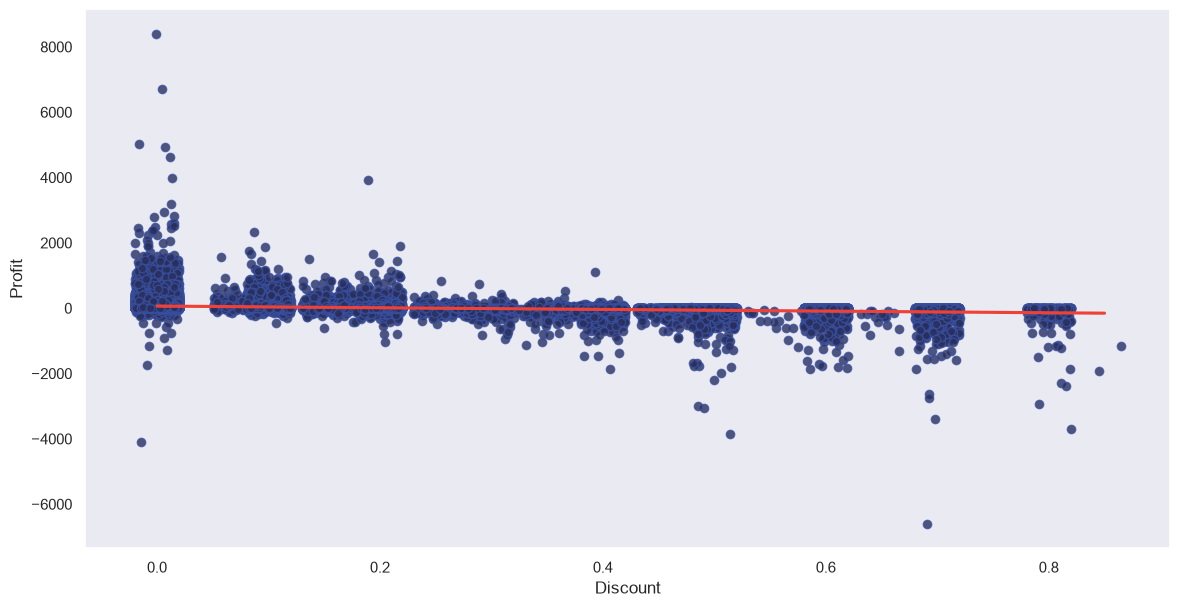

In [95]:
sns.set_theme()

fig, ax = plt.subplots(figsize=(14,7))

ax = sns.regplot(
    data=df,
    x='Discount',
    y='Profit',
    color='#292E5A',
    line_kws=dict(
        color= "#F04137"),
    scatter_kws=dict(
        edgecolor= '#3950A0',   # Marker edge color
        linewidths= 1),
    marker='o',
    x_jitter=.02
)
#ax.set_ylim(-0.05,0.95)
#ax.set_xlim(-4500,5000)
ax.grid(False)

In [99]:
# Business Question 14:
# What is the direct impact of giving Discounts on overall Profitability? Is there a point where discounting completely destroys margins?

# Answer:
# Discount from 0 up to 20% shows a minimal reduction in profit and moderate-high gains in every transaction. But more than 20% Discount, profit starts
# to decline and losses dramatically accumulates. 0 to 20% is the sweet spot for gaining profits and minimal falloffs